# Predicting Heart Diseases

#### Group Name: Group 6




####  Group Members: Adam Irfan, Piyush Nawale, Bhuvaneshwari Neela, Sathvika Muthyala


This report outlined as follows:
- [Introduction](#1)  
    + [Phase 1 Summary](#2)
    + [Report Overview](#3)
    + [Overview of Methodology](#4)
- [Predictive Modelling](#5)
- [Feature Selection](#6)
- [Model Fitting & Tuning](#7)
- [Model Comparison](#8)
- [Critique & Limitations](#9)
- [Summary & Conclusions](#10)
    + [Project Summary](#11)
    + [Summary of Findings](#12)
    + [Conclusions](#13)
- [References](#14)

## Introduction <a class="anchor" id="1"></a>

The aim of this case study is to build and evaluate five distinct binary classifiers to forecast the likelihood of heart disease in individuals using a range of medical factors. The dataset used in this analysis is obtained from the UCI Machine Learning Repository(Kaggle) and includes essential features such as age, gender, blood pressure, cholesterol levels, among other health-related metrics. The target variable is divided, representing either the presence or absence of heart disease. Through the application and assessment of various classification algorithms, this study seeks to determine the most accurate model for predicting heart disease, thereby aiding in improved diagnosis and preventative healthcare measures.The dataset has the total 1.1k observations.

## Phase 1 Summary <a class="anchor" id="2"></a>

In Phase 1 of our project, we started by analyzing a heart disease dataset, looking at important factors like age, sex, chest pain type, blood pressure, cholesterol, blood sugar, ECG results, maximum heart rate, exercise-induced angina, ST depression, and ST segment slope. We cleaned the data and used various methods to explore and understand the data, including statistics, graphs, and correlation studies. Our initial findings showed that high blood pressure, high cholesterol, and exercise-induced angina are significant factors for heart disease. These results will help us in Phase 2, where we'll create new features, develop models using Logistic Regression, Random Forest, KNN, SVM, and Gradient Boosting and thoroughly evaluate them. The insights from Phase 1 will guide us in building accurate models to predict heart disease risk, which can help in early diagnosis and treatment.

## Report Overview <a class="anchor" id="3"></a>

The Phase 2 report starts by loading necessary libraries like pandas, numpy, and scikit-learn for data handling and model building. The data is then first prepared by removing outliers then further scaling and encoding the features. The report tests several classification models, such as Random Forest, Gradient Boosting, Support Vector Machines, K-Nearest Neighbors, and Logistic Regression. Each model is fine-tuned and evaluated using cross-validation to find the best performance. Evaluation metrics include accuracy, precision, recall, F1 score,F2 score and ROC-AUC. The report ends with a comparison of how well the models performed, using visual aids like confusion matrices and ROC curves, to identify the best model for predicting chances of heart disease.

## Overview of Methodology <a class="anchor" id="4"></a>

We are using the following five classifiers to predict the target feature:
1. Support Vector Machine(SVM)
2. Gradient Boosting Classifier
3. Random Forest Classifier
4. KNN Classifier
5. Logistic Regression

The predictive modeling journey begins with preparing the data, a crucial step for accurate analysis. We start by loading the dataset into a pandas DataFrame and removing outliers. Then, we transform categorical data into binary values using methods like one-hot encoding, making it suitable for machine learning algorithms. Next, we define our target variable.

Moving forward, we focus on feature selection to enhance the model's performance. This involves using tools like the chi-square test and feature scaling. These steps ensure the model can be evaluated on new, unseen data, thereby verifying its effectiveness. We split the dataset into training and testing sets, typically allocating 70-80% for training and 20-30% for testing.

Subsequently, we train several machine learning models, including Random Forest, SVM, Gradient Boosting, KNN, and Logistic Regression. Each model is assessed using metrics like accuracy, precision, recall, F1-score,F2-score and AUC-ROC. ROC curves and AUC scores help us visualize how well each model performs. Finally, we compare the models based on these metrics, select the best one, and fine-tune it before deployment. This comprehensive approach ensures our predictive modeling process is thorough and effective.

### Loading the dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, make_scorer, fbeta_score,accuracy_score, precision_score, recall_score, classification_report,confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Phase2_Group45.csv')

### Outlier Removal
The basic requirement for testing the model's performance is that it should be free of outliers to ensure accurate results. Here, we used a basic technique for outlier removal by calculating the interquartile range (IQR), defined as the difference between the third quartile (Q3, 0.75) and the first quartile (Q1, 0.25). Specifically, IQR = Q3 - Q1.

In [ ]:
num_col = ['age', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_heart_rate', 'old_peak']
Q1 = df[num_col].quantile(0.25)
Q3 = df[num_col].quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
up = Q3 + 1.5 * IQR
new_df = df[~((df[num_col] < low) | (df[num_col] > up)).any(axis=1)]


## Predictive Modelling <a class="anchor" id="5"></a>

The primary requirement for a machine learning model is that it can only process numerical values, not categorical data. Therefore, it is necessary to perform one-hot encoding to convert categorical features into binary values. This ensures that each category has a distinct representation, enabling the algorithm to make accurate predictions. This transformation can be achieved using the get_dummies function from the pandas library

In [ ]:
cat_col = ['sex', 'pain_type', 'resting_ecg', 'ex_angina', 'st_slope']
df_new = pd.get_dummies(new_df, columns=cat_col, drop_first=True)
df_new.head()

,age,resting_bp,cholesterol,fasting_bs,max_heart_rate,old_peak,heart_disease,sex_M,pain_type_ATA,pain_type_NAP,pain_type_TA,resting_ecg_Normal,resting_ecg_ST,ex_angina_Y,st_slope_Flat,st_slope_Up
0,40,140,289,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,1,0,1,0,1,0,0,0,1


### Target Variable Encoding
The target variable, also known as the dependent variable in the dataset, is used to measure metrics such as accuracy, precision, recall, and F1 score. It represents the outcome that the model predicts. Therefore, we store it separately from the other features to facilitate accurate predictions.

In [ ]:
X = df_new.drop('heart_disease', axis=1)
y = df_new['heart_disease']

### Splitting Data in  Train and Test
This is a crucial part of the model's functioning as we split the data into training and testing sets for prediction. This step involves using the training data to teach the model to recognize patterns in the data, while the test data is used to evaluate the model's performance on new, unseen data. Here, the 'test_size" is set to 0.3, which means 30% of the data is used for testing and 70% for training. The 'random_state', set to 66, specifies the random seed value used to ensure reproducibility of the data splitting process

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=66)

### Features Scaling
Feature scaling is a crucial step in the preprocessing of data before applying many machine learning algorithms. This is necessary because features often have numerical values measured on different scales, which can adversely affect the model's performance. To avoid any misleading influences from features with larger numerical ranges, we need to scale them to a certain level.

One common feature scaling technique is MinMaxScaler, provided by the sklearn.preprocessing module in the scikit-learn library. MinMaxScaler transforms the features to a fixed range, usually [0,1]. This ensures that all features contribute equally to the model, improving its performance and reliability

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Feature Selection <a class="anchor" id="6"></a>
We have selected the 9 features because limiting the features will help simplify the model and make it less prone to overfitting. Selecting the best and most important features will lead to better model performance. By focusing on the top 9 features, it will be easier to determine which number of features works best with each classifier. We used the Chi-Square test to evaluate the independence of the features with respect to the target variable. The Chi-Square test is very efficient and fast, and it helps identify the features that are most relevant for the classification task.

In [ ]:
selector = SelectKBest(score_func=chi2, k=9)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)


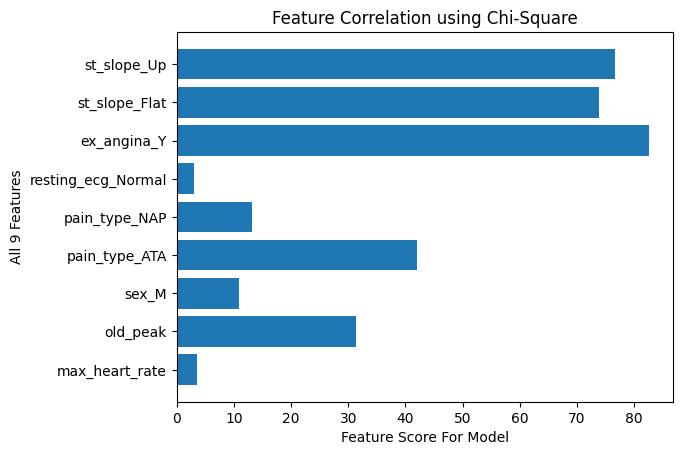

In [ ]:
feature_scores = selector.scores_
selected_features = X_train.columns[selector.get_support()]
plt.barh(range(len(selected_features)), feature_scores[selector.get_support()])
plt.yticks(range(len(selected_features)), selected_features)
plt.xlabel('Feature Score For Model')
plt.ylabel('All 9 Features')
plt.title('Feature Correlation using Chi-Square')
plt.show()

We have plotted the observations from the Chi-Square test and can see that the most important feature, with a score of over 80, is "ex_angina_Y" which is Exercise angina in patients is indicated by 'Y' for yes. This indicates a strong association between "ex_angina_Y" and the target variable "heart_disease".

## Model Fitting & Tunning  <a class="anchor" id="7"></a>
Model fitting involves training a machine learning model on the dataset. The main goal is to learn the patterns and structure within the data. A well-fitted model performs well and achieves high accuracy in predictions.

Model tuning involves adjusting the hyperparameters of a machine learning model to enhance its performance. Hyperparameters are not fixed and need to be optimized for the model. In this phase, different hyperparameters are tested to determine which ones perform the best for the given dataset. This process is further evaluated using cross-validation. Based on the accuracy scores obtained from cross-validation, the best hyperparameters are selected for final model training.




#### Support Vector Machine.
Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. It works by finding the hyperplane that best separates the data into different classes. Cross-validation with a 5-fold split is often used to evaluate the model's performance. After evaluating the performance of all parameters, we select the best ones.

Best parameters:  {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Cross-validation accuracy score for 5 folds:  0.8571815718157183


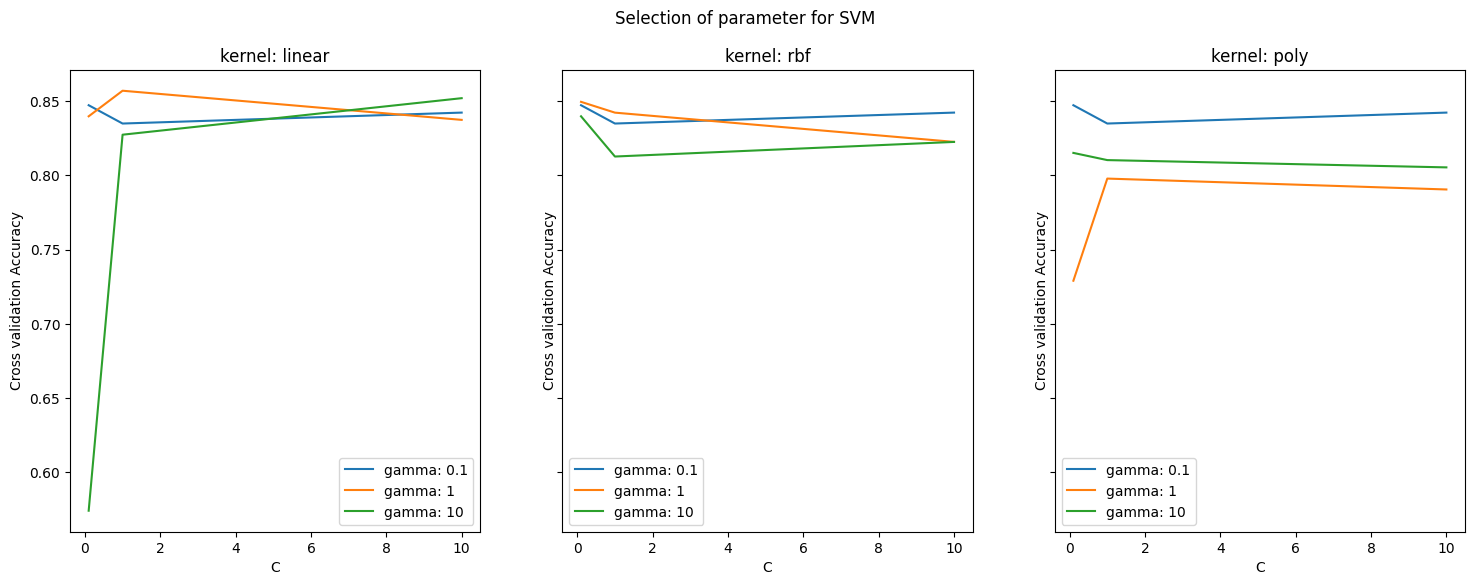

In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': [0.1, 1, 10]
}

grid_search_svm = GridSearchCV(estimator=SVC(probability=True), param_grid=param_grid_svm, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train_selected, y_train)

print("Best parameters: ", grid_search_svm.best_params_)
print("Cross-validation accuracy score for 5 folds: ", grid_search_svm.best_score_)

accuracy_scores = grid_search_svm.cv_results_['mean_test_score'].reshape(len(param_grid_svm['C']), len(param_grid_svm['kernel']), len(param_grid_svm['gamma']))

fig, axes = plt.subplots(1, len(param_grid_svm['kernel']), figsize=(18, 6), sharey=True)
for idx, kernel in enumerate(param_grid_svm['kernel']):
    for i, gamma in enumerate(param_grid_svm['gamma']):
        axes[idx].plot(param_grid_svm['C'], accuracy_scores[:, idx, i], label=f'gamma: {gamma}')
    axes[idx].set_title(f'kernel: {kernel}')
    axes[idx].set_xlabel('C')
    axes[idx].set_ylabel('Cross validation Accuracy')
    axes[idx].legend()
plt.suptitle('Selection of parameter for SVM')
plt.show()

#### Gradient Boosting Classifier
Gradient Boosting Classifier is an important machine learning algorithm that works by making an initial prediction and then calculating the residuals (errors) between the actual target values and the predicted values. It then fits a weak learner to these residuals, where the learner's job is to predict the residuals from the previous step.

Best parameters:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Cross-validation accuracy score for 5 folds:  0.8547726588376996


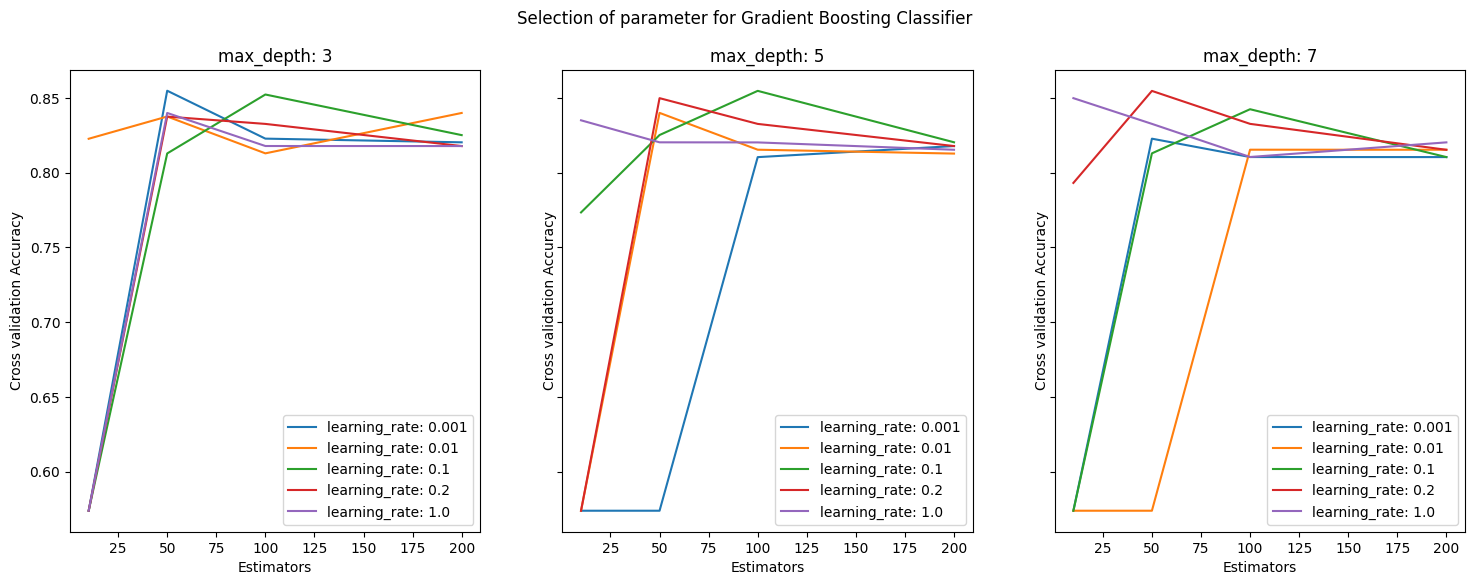

In [ ]:
param_grid_gbc = {
    'n_estimators': [10, 50, 100, 200],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 1.0],
    'max_depth': [3, 5, 7]
}

grid_search_gbc = GridSearchCV(estimator=GradientBoostingClassifier(random_state=66), param_grid=param_grid_gbc, cv=5, scoring='accuracy')
grid_search_gbc.fit(X_train_selected, y_train)

print("Best parameters: ", grid_search_gbc.best_params_)
print("Cross-validation accuracy score for 5 folds: ", grid_search_gbc.best_score_)

results_gbc = pd.DataFrame(grid_search_gbc.cv_results_)

accuracy_scores = results_gbc['mean_test_score'].values.reshape(len(param_grid_gbc['n_estimators']), len(param_grid_gbc['learning_rate']), len(param_grid_gbc['max_depth']))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for idx, depth in enumerate(param_grid_gbc['max_depth']):
    for i, lr in enumerate(param_grid_gbc['learning_rate']):
        axes[idx].plot(param_grid_gbc['n_estimators'], accuracy_scores[:, i, idx], label=f'learning_rate: {lr}')
    axes[idx].set_title(f'max_depth: {depth}')
    axes[idx].set_xlabel('Estimators')
    axes[idx].set_ylabel('Cross validation Accuracy')
    axes[idx].legend()
plt.suptitle('Selection of parameter for Gradient Boosting Classifier')
plt.show()

#### Random Forest Classifier
Random Forest Classifier builds multiple decision trees during training and uses the bagging technique. The base learners in a random forest are decision trees. Each tree is grown using a random subset of the training data. At each split in the tree, a random subset of features is selected, and the best feature from this subset is used to perform the split.

Best parameters:  {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Cross-validation accuracy score for 5 folds:  0.8375188196326407


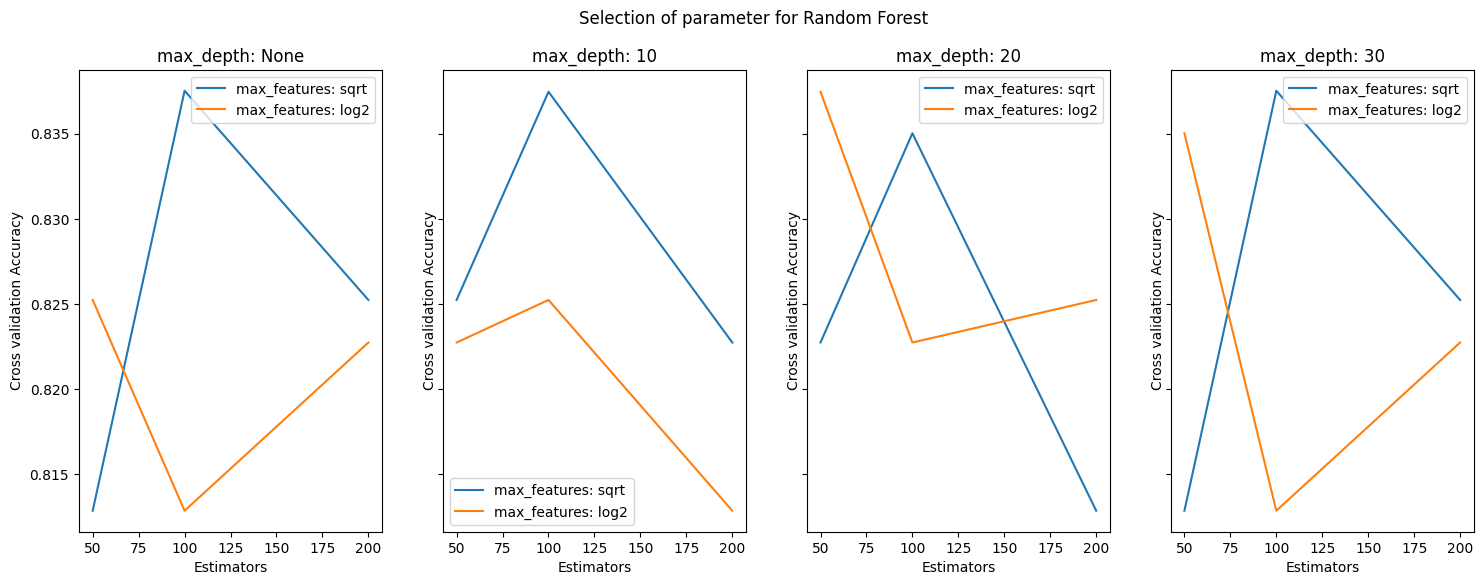

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30]
}

grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=66), param_grid=param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train_selected, y_train)

print("Best parameters: ", grid_search_rf.best_params_)
print("Cross-validation accuracy score for 5 folds: ", grid_search_rf.best_score_)

results_rf = pd.DataFrame(grid_search_rf.cv_results_)

accuracy_scores = results_rf['mean_test_score'].values.reshape(len(param_grid_rf['n_estimators']), len(param_grid_rf['max_features']), len(param_grid_rf['max_depth']))

fig, axes = plt.subplots(1, len(param_grid_rf['max_depth']), figsize=(18, 6), sharey=True)
for idx, depth in enumerate(param_grid_rf['max_depth']):
    for i, max_feature in enumerate(param_grid_rf['max_features']):
        axes[idx].plot(param_grid_rf['n_estimators'], accuracy_scores[:, i, idx], label=f'max_features: {max_feature}')
    axes[idx].set_title(f'max_depth: {depth}')
    axes[idx].set_xlabel('Estimators')
    axes[idx].set_ylabel('Cross validation Accuracy')
    axes[idx].legend()
plt.suptitle('Selection of parameter for Random Forest')
plt.show()

#### KNN Classifier
The K-Nearest Neighbors (KNN) algorithm is a simple, supervised machine learning algorithm. The KNN model predicts the class to which a data point belongs based on the classes of its nearest neighbors. The common distance metrics used in the KNN model include Euclidean distance, Manhattan distance, and Minkowski distance.

Best parameters found:  {'n_neighbors': 12, 'p': 1}
Best cross-validation accuracy score:  0.8644685335742247


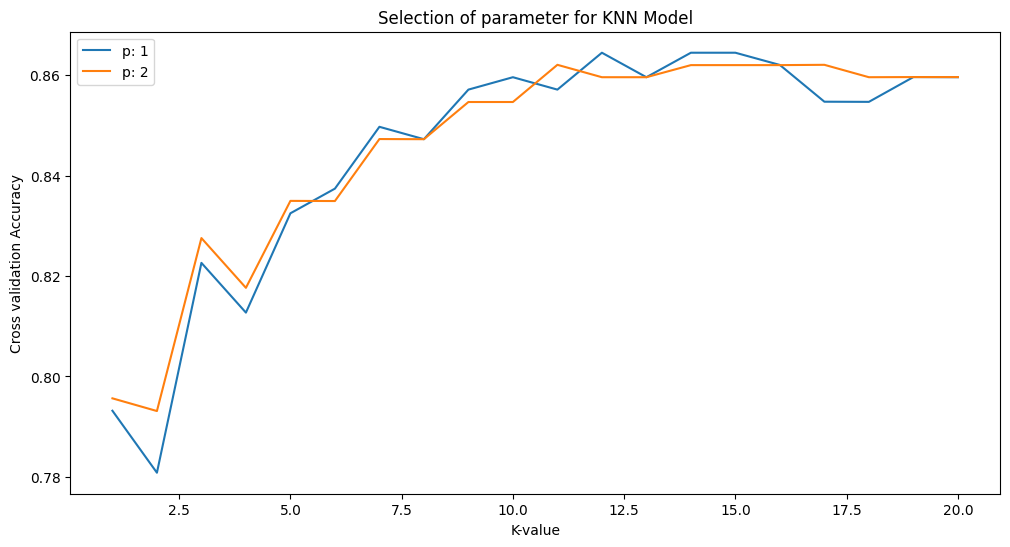

In [ ]:
param_grid_knn = {
    'n_neighbors': list(range(1, 21)),
    'p': [1, 2]
}

grid_search_knn = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train_selected, y_train)

print("Best parameters found: ", grid_search_knn.best_params_)
print("Best cross-validation accuracy score: ", grid_search_knn.best_score_)

results_knn = pd.DataFrame(grid_search_knn.cv_results_)
scores_knn = np.array(results_knn['mean_test_score']).reshape(len(param_grid_knn['n_neighbors']), len(param_grid_knn['p']))

plt.figure(figsize=(12, 6))
for idx, p_value in enumerate(param_grid_knn['p']):
    plt.plot(param_grid_knn['n_neighbors'], scores_knn[:, idx], label=f'p: {p_value}')
plt.xlabel('K-value')
plt.ylabel('Cross validation Accuracy')
plt.title('Selection of parameter for KNN Model')
plt.legend()
plt.show()

#### Logistic Regression
Logistic Regression is a supervised learning algorithm used for binary classification tasks. The model works by initializing a set of weights for the coefficients, typically with small random values or zeros. A linear combination of the input features is then computed using these weights, and this value is passed through the sigmoid function to represent the probability of the positive class.

C:\Users\SIDDHARTH\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\SIDDHARTH\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\SIDDHARTH\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\SIDDHARTH\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\SIDDHARTH\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached w

Best parameters found:  {'C': 1, 'max_iter': 100, 'penalty': 'l2'}
Best cross-validation accuracy score:  0.8670280036133693


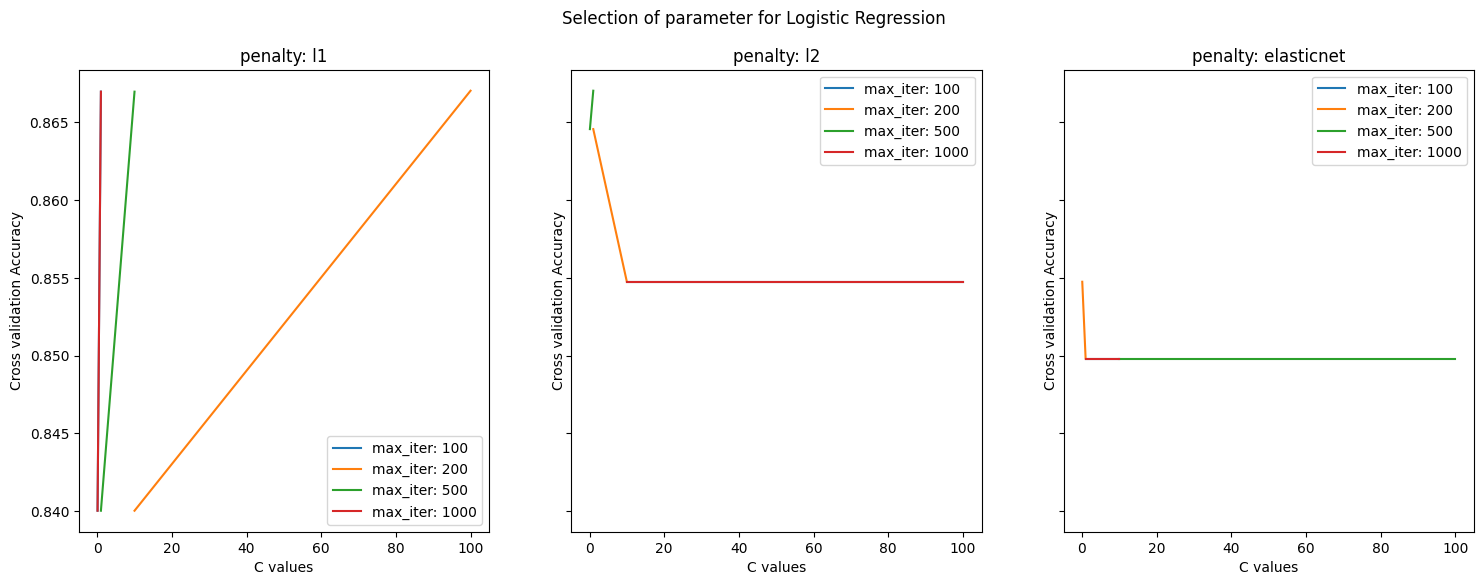

In [ ]:

param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.1, 1, 10, 100],
    'max_iter': [100, 200, 500, 1000]
}

grid_search_lr = GridSearchCV(estimator=LogisticRegression(solver='saga', random_state=66), param_grid=param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train_selected, y_train)

print("Best parameters found: ", grid_search_lr.best_params_)
print("Best cross-validation accuracy score: ", grid_search_lr.best_score_)

results_lr = pd.DataFrame(grid_search_lr.cv_results_)

scores_lr = np.array(results_lr['mean_test_score']).reshape(len(param_grid_lr['penalty']), len(param_grid_lr['C']), len(param_grid_lr['max_iter']))

fig, axes = plt.subplots(1, len(param_grid_lr['penalty']), figsize=(18, 6), sharey=True)
for idx, penalty in enumerate(param_grid_lr['penalty']):
    for i, max_iter in enumerate(param_grid_lr['max_iter']):
        axes[idx].plot(param_grid_lr['C'], scores_lr[idx, :, i], label=f'max_iter: {max_iter}')
    axes[idx].set_title(f'penalty: {penalty}')
    axes[idx].set_xlabel('C values')
    axes[idx].set_ylabel('Cross validation Accuracy')
    axes[idx].legend()
plt.suptitle('Selection of parameter for Logistic Regression')
plt.show()

## Model Comparison <a class="anchor" id="8"></a>
In this section, we select the best hyperparameters obtained from cross-validation based on accuracy. These optimal hyperparameters are then used to configure a dictionary of models for further performance evaluation


In [ ]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_features='sqrt', max_depth=10, random_state=66),
    'SVM': SVC(C=1, gamma=0.1, kernel='rbf', probability=True, random_state=66),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=3, random_state=66),
    'KNN': KNeighborsClassifier(n_neighbors=12, p=1),
    'Logistic Regression': LogisticRegression(C=1, penalty='l2', max_iter=100, random_state=66)
}


#### Cross Validation of the Model
To ensure that each fold maintains the same proportion of class labels as the original dataset, we use the StratifiedKFold function, which is especially important for imbalanced data. However, our data is balanced based on the results from phase 1. In this phase, we perform cross-validation on each model to prevent overfitting, using 5 folds. The accuracy of each model is then studied.

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=66)
results = {}
for name, model in models.items():
    aucs = cross_val_score(model, X_train_selected, y_train, cv=kf, scoring='roc_auc')
    results[name] = aucs
    print(f'{name} - AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}')


Random Forest - AUC: 0.9210 ± 0.0220
SVM - AUC: 0.9193 ± 0.0291
Gradient Boosting - AUC: 0.9277 ± 0.0217
KNN - AUC: 0.9199 ± 0.0279
Logistic Regression - AUC: 0.9265 ± 0.0241


#### Paired T-Test of All Model
In this section, we perform a paired t-test to evaluate the performance of the Area Under the Curve (AUC) for each model. This test is used to compare the AUCs obtained through cross-validation and to determine whether the performance of the models is significantly different or similar.

The results of the paired t-tests suggest high p-values, all higher than the threshold of 0.05, indicating no significant differences between the models. Therefore, our models' performances are quite similar to each other.

In [ ]:
model_names = list(models.keys())
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        t_stat, p_value = ttest_rel(results[model_names[i]], results[model_names[j]])
        print(f'Paired t-test between {model_names[i]} and {model_names[j]}: t_stat={t_stat:.4f}, p_value={p_value:.4f}')


Paired t-test between Random Forest and SVM: t_stat=0.1686, p_value=0.8743
Paired t-test between Random Forest and Gradient Boosting: t_stat=-1.2871, p_value=0.2675
Paired t-test between Random Forest and KNN: t_stat=0.1785, p_value=0.8670
Paired t-test between Random Forest and Logistic Regression: t_stat=-0.6838, p_value=0.5317
Paired t-test between SVM and Gradient Boosting: t_stat=-1.1862, p_value=0.3012
Paired t-test between SVM and KNN: t_stat=-0.0796, p_value=0.9403
Paired t-test between SVM and Logistic Regression: t_stat=-1.2205, p_value=0.2893
Paired t-test between Gradient Boosting and KNN: t_stat=1.2010, p_value=0.2960
Paired t-test between Gradient Boosting and Logistic Regression: t_stat=0.1802, p_value=0.8657
Paired t-test between KNN and Logistic Regression: t_stat=-1.7409, p_value=0.1567


### Model Evaulation


Model: Random Forest
Accuracy: 0.8276
Precision: 0.7750
Recall: 0.8378
F1 Score: 0.8052
F2 Score: 0.8245
ROC AUC: 0.8965
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       100
           1       0.78      0.84      0.81        74

    accuracy                           0.83       174
   macro avg       0.82      0.83      0.83       174
weighted avg       0.83      0.83      0.83       174

Model: SVM
Accuracy: 0.8448
Precision: 0.8133
Recall: 0.8243
F1 Score: 0.8188
F2 Score: 0.8221
ROC AUC: 0.9075
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       100
           1       0.81      0.82      0.82        74

    accuracy                           0.84       174
   macro avg       0.84      0.84      0.84       174
weighted avg       0.85      0.84      0.84       174

Model: Gradient Boosting
Accuracy: 0.8391
Precision: 0.7949
Recall: 0.8378
F1 Score: 0.8158
F2 Score: 0.8289
ROC A

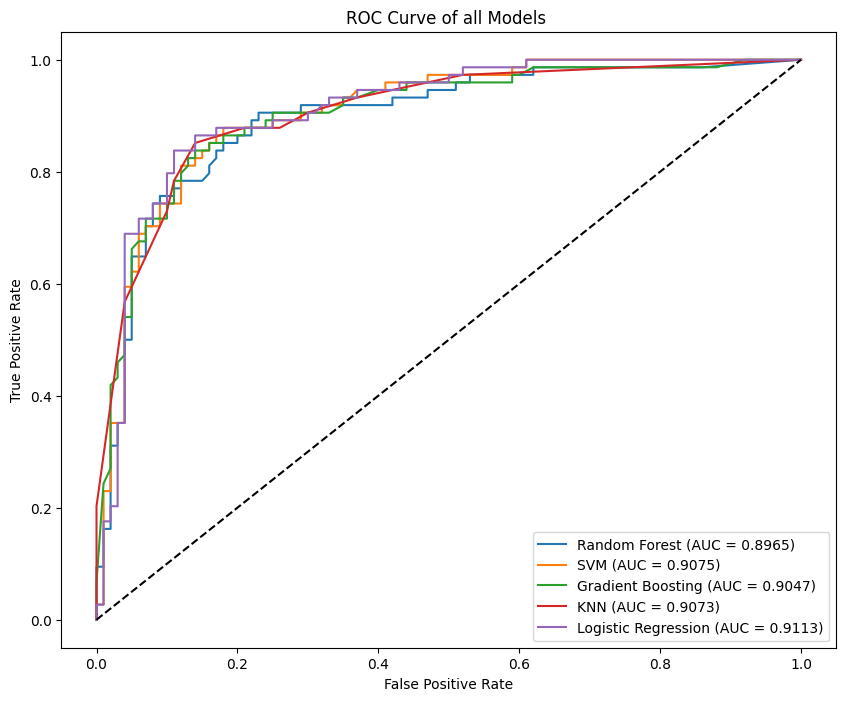

In [ ]:
f1_scores = {}
f2_scores = {}
roc_curves = plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    y_proba = model.predict_proba(X_test_selected)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    roc_auc = roc_auc_score(y_test, y_proba)
    f1_scores[name] = f1
    f2_scores[name] = f2

    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"F2 Score: {f2:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of all Models ')
plt.legend(loc='lower right')
plt.show()

In the first step, we performed a paired t-test on all models to obtain a general comparison of their performances. The results suggested that there is no significant difference in the performance of each model. Therefore, the further steps involve evaluating the best model performance. We followed a series of steps to determine which model best fits our requirements and helps us predict heart disease in individuals.

We evaluated the performance metrics of all models, including accuracy, precision, recall, F1 score, F2 score, and ROC AUC. The output showed that the accuracy of the k-Nearest Neighbors (KNN) and Logistic Regression models was the highest. However, accuracy alone is not a sufficient parameter for our evaluation as it reflects the model's output for true positives and true negatives.

Given the medical context of our model, it is crucial to focus on reducing false negatives, meaning the prediction of a person having the disease should be accurate to ensure the best performance. The best parameter to address this is recall, which emphasizes minimizing false negatives. The best recall was again obtained with the KNN and Logistic Regression models, due to their identical confusion matrices.

We also considered the F2 score, which gives more weight to recall (false positives) with
beta value as 2(β=2). Both models showed the same F2 scores. The final evaluation involved ROC AUC visualization, which provided a clear report on model performance. The ROC AUC curve indicated that the area under the curve for Logistic Regression is 0.9113, while for the KNN model, it is 0.9073.

The end evaluation suggests that we should choose Logistic Regression as the best model, as it fits our dataset better than the others, despite the minute difference between KNN and Logistic Regression.

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test_selected)
    cm = confusion_matrix(y_test, y_pred)
    print(f'Confusion Matrix for {name}:')
    print(cm)

Confusion Matrix for Random Forest:
[[82 18]
 [12 62]]
Confusion Matrix for SVM:
[[86 14]
 [13 61]]
Confusion Matrix for Gradient Boosting:
[[84 16]
 [12 62]]
Confusion Matrix for KNN:
[[86 14]
 [11 63]]
Confusion Matrix for Logistic Regression:
[[86 14]
 [11 63]]


## Critique & Limitations  <a class="anchor" id="9"></a>

## Strengths

1. **Complete Methodology:** We tried using five different machine learning classifiers: SVM, Gradient Boosting, Random Forest, KNN, and Logistic Regression. This allows multiple perspectives in evaluating the model's performance and reliability. Each classifier has undergone accurate tuning and assessment for comparison.

2. **Feature Selection:** We ensured model efficiency and interpretability by using the Chi-Square test for feature selection, including only the most relevant features. This step minimized overfitting and simplified the model, enhancing its performance.

3. **Hyperparameter Tuning:** We have carefully tuned each model with the best combination of parameters using GridSearchCV. This systematic approach maximized model performance and efficacy.

4. **Cross-Validation:** We have established a very robust evaluation framework using cross-validation techniques such as StratifiedKFold, mitigating overfitting and ensuring the models' generalizability to unseen data.

5. **Evaluation Metrics:** We have followed a comprehensive suite of evaluation metrics that include accuracy, precision, recall, F1 score, and ROC-AUC. This holistic approach provided a balanced assessment of model performance.

6. **Visualization:** We have included very clear visual aids like ROC curves, confusion matrices, and feature importance plots, providing clear insights into model performance and facilitating result interpretation.

## Weaknesses

1. **Data Preprocessing:** We have used basic methods of outlier removal by the IQR method and MinMaxScaler for scaling. Using more sophisticated techniques might potentially improve model performance.

2. **Imbalance Handling:** We treated the dataset as balanced and potentially overlooked significant class imbalances. Employing techniques like SMOTE or cost-sensitive learning could help address the issue.

3. **Model Complexity:** Complex models like Gradient Boosting and Random Forest might incur higher computational costs and longer training times. Simpler models could achieve similar performance with fewer resources.

4. **Model Interpretability:** Some models, like Random Forest and Gradient Boosting, are harder to interpret due to their "black box" nature. Models that have clearer interpretability, like Logistic Regression, might be preferred in certain settings.

5. **Assumption of Feature Independence:** Chi-Square considers each feature to be independent of the others, which is not true in the case of medical data. This may be improved by more advanced methods of feature selection.

6. **Limitations of ROC-AUC:** ROC-AUC might not be the best way to deal with very imbalanced datasets. Precision-Recall curves might then provide additional insights in such a case.

7. **Problem in Model Selection:** When we calculated the confusion matrices of all the algorithms, we found that two models have the same confusion matrix. This leads to a problem in selecting the model for better performance.

By acknowledging the following strengths and weaknesses, our approach aims to provide a balanced view of predictive modeling for heart diseases. Addressing such limitations in future work can lead to models that are more robust and applicable in the real world.

## Summary & Conclusions <a class="anchor" id="10"></a>

## Summary and Conclusions

#### 1. Project Summary <a class="anchor" id="11"></a>
In our project on the prediction of heart diseases, we conducted comprehensive analysis in two phases using a dataset obtained from the UCI Machine Learning Repository, which includes critical health metrics.

**Phase 1:**
We started with the cleaning of our dataset for inconsistencies and outliers, with an emphasis on critical metrics such as age, cholesterol levels, and blood pressure. We performed exploratory data analysis to understand the relationships between different features and the presence of heart disease. It included basic statistical analysis and visualization techniques to identify important factors.

**Phase 2:**
We created new features and prepared the data by encoding categorical variables and scaling the numerical features. Subsequently, we applied and fine-tuned five machine learning classifiers: Support Vector Machine (SVM), Gradient Boosting Classifier, Random Forest Classifier, K-Nearest Neighbors (KNN), and Logistic Regression. Each model was evaluated using cross-validation and metrics such as accuracy, precision, recall, F1 score, and ROC-AUC. We further performed paired t-tests to statistically compare the performances of models with one another and, based on that, we determined the most effective algorithm.

#### 2. Summary of Findings <a class="anchor" id="12"></a>
Our findings highlighted several key aspects with regard to the prediction of heart disease:

**Feature Importance:**
- High cholesterol, high blood pressure, and exercise-induced angina were recognized as important factors in predicting heart disease.
- The feature 'ex_angina_Y' showed the highest importance score in the Chi-Square test.

**Model Performance:**

- Gradient Boosting Classifier: The highest performance with AUC equal to 0.9277, closely followed by Logistic Regression with an AUC of 0.9265, then Random Forest with an AUC of 0.9210.
- The effect of increased accuracy, however, does not in itself provide the best parameter for choosing the optimum model for our purpose.
- Our model puts its main emphasis on minimizing the False Positive rate; thus, we did evaluation based on recall and the ROC-AUC curve.
- The recall and ROC-AUC results led us to conclude that Logistic Regression is the best fit for our model.

**Statistical Comparison:**
- The paired t-test results on the performance between models were insignificant and showed that although some models had better metrics, the performance differences were statistically not significant.

#### 3. Conclusions <a class="anchor" id="13"></a>
This project tried to apply various machine learning algorithms to predict heart disease. The main objectives were thus fulfilled: the identification of the key health metrics considerably affecting heart disease prediction and the comparison of different classifiers in their effectiveness.

**Goals Met:**
- We confirmed that machine learning can be used to predict patients at risk of heart disease and therefore aid in early diagnosis and treatment.
- The models developed can be used in the improvement of the processes of clinical decision-making by offering a data-driven approach to the prediction of heart disease.

**Future Work:**
- Further research could be done to incorporate advanced algorithms like deep learning into the model for better prediction accuracy.
- The dataset could be expanded with diverse populations and more health metrics for the model to be generalizable.

**Implications:**
- The study emphasizes the importance of preventive healthcare and the potential of machine learning in transforming clinical practices.
- Accurate prediction of the risk of heart disease allows healthcare providers to enact timely interventions that would improve patient outcomes and reduce healthcare costs.

This comprehensive analysis demonstrates the potential of machine learning in healthcare and serves as a foundational framework for future research and application within this domain.

## References <a class="anchor" id="14"></a>

fedesoriano. (September 2021). Heart Failure Prediction Dataset. Retrieved [April 11, 2024] from https://www.kaggle.com/fedesoriano/heart-failure-prediction.

Ouyang, S. (2022). Research of Heart Disease Prediction Based on Machine Learning. In 2022 5th International Conference on Advanced Electronic Materials, Computers and Software Engineering (AEMCSE), Wuhan, China (pp. 315-319).

Yadav, D. P., Saini, P., & Mittal, P. (2021). Feature Optimization Based Heart Disease Prediction using Machine Learning. In 2021 5th International Conference on Information Systems and Computer Networks (ISCON), Mathura, India (pp. 1-5).

H. Yu, "Analysis and Prediction of Heart Disease Based on Machine Learning Algorithms," 2023 8th International Conference on Intelligent Computing and Signal Processing (ICSP), Xi'an, China, 2023, pp. 1418-1423

Jeyaraman, Gowri.(2022). Heart Disease Prediction using Machine Learning. International Journal of Innovative Technology and Exploring Engineering, Vol 11, pp. 29-32.

Rahman, M. M., Rana, M. R., Alam, M. N. A., Khan, M. S. I., & Uddin, K. M. M. M. (2022). A web-based heart disease prediction system using machine learning algorithms. Network Biology, Vol 12(2), pp. 64-80.

Prof. S. B. Pagrut, S. B., Ozair, M. A., Ingle, S., Dharangaonkar, R., & Mundhada, A. (2023). Heartcare: Heart Disease Detection using Machine Learning. *International Journal of Advanced Research in Science, Communication and Technology (IJARSCT), Vol 3

Kanimozhi, S. & Sivanandan, N.(2024). Machine learning based heart disease prediction system. E3S Web of Conferences, pp.491.